<a href="https://colab.research.google.com/github/saikrishna5655/Hospital_readmission_prediction/blob/main/Hospital_Readmission_Prediction_Part1_Exploration.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🏥 Hospital Readmission Prediction System
## Part 1: Data Exploration & Cleaning

### Problem Statement
Hospitals face significant financial penalties when patients are readmitted within 30 days of discharge. This project aims to predict which diabetic patients are at high risk of readmission, enabling early intervention and better patient care.

### Dataset
- **Source:** UCI Machine Learning Repository - Diabetes 130-US Hospitals (1999-2008)
- **Size:** 101,766 hospital encounters from 71,518 unique patients
- **Target:** Predict readmission within 30 days


In [2]:
# Import essential libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Configure display settings
pd.set_option('display.max_columns', None)
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

print(" Libraries imported successfully")

✓ Libraries imported successfully


### Libraries Used
- **pandas**: Working with tabular data (like Excel but in Python)
- **numpy**: Handling numerical operations and missing values
- **matplotlib & seaborn**: Creating visualizations to understand patterns


In [3]:
# Load the diabetes hospital dataset
df = pd.read_csv('/content/diabetic_data.csv')

print(f"Dataset loaded successfully!")
print(f"Dataset size: {len(df):,} rows × {len(df.columns)} columns")

Dataset loaded successfully!
Dataset size: 101,766 rows × 50 columns


In [4]:
# Display first 5 rows to understand data structure
df.head()

,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,payer_code,medical_specialty,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,number_inpatient,diag_1,diag_2,diag_3,number_diagnoses,max_glu_serum,A1Cresult,metformin,repaglinide,nateglinide,chlorpropamide,glimepiride,acetohexamide,glipizide,glyburide,tolbutamide,pioglitazone,rosiglitazone,acarbose,miglitol,troglitazone,tolazamide,examide,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,2278392,8222157,Caucasian,Female,[0-10),?,6,25,1,1,?,Pediatrics-Endocrinology,41,0,1,0,0,0,250.83,?,?,1,NaN,NaN,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,NO
1,149190,55629189,Caucasian,Female,[10-20),?,1,1,7,3,?,?,59,0,18,0,0,0,276,250.01,255,9,NaN,NaN,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Up,No,No,No,No,No,Ch,Yes,>30
2,64410,86047875,AfricanAmerican,Female,[20-30),?,1,1,7,2,?,?,11,5,13,2,0,1,648,250,V27,6,NaN,NaN,No,No,No,No,No,No,Steady,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Yes,NO
3,500364,82442376,Caucasian,Male,[30-40),?,1,1,7,2,?,?,44,1,16,0,0,0,8,250.43,403,7,NaN,NaN,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Up,No,No,No,No,No,Ch,Yes,NO
4,16680,42519267,Caucasian,Male,[40-50),?,1,1,7,1,?,?,51,0,8,0,0,0,197,157,250,5,NaN,NaN,No,No,No,No,No,No,Steady,No,No,No,No,No,No,No,No,No,No,Steady,No,No,No,No,No,Ch,Yes,NO


### Initial Observations
The dataset contains hospital encounter records with:
- **Patient identifiers**: encounter_id (unique visit) and patient_nbr (unique patient)
- **Demographics**: age, gender, race
- **Clinical data**: diagnoses, medications, lab procedures
- **Outcome**: readmitted (our target variable - what we want to predict)

In [5]:
# Check data types and get column information
print("Dataset Information:")
print("=" * 60)
print(f"Total columns: {len(df.columns)}")
print(f"\nData types breakdown:")
print(df.dtypes.value_counts())

Dataset Information:
Total columns: 50

Data types breakdown:
object    37
int64     13
Name: count, dtype: int64


## 🎯 Understanding Our Target: Readmission

The `readmitted` column tells us if a patient returned to the hospital:
- **<30**: Readmitted within 30 days (HIGH RISK - what we want to predict!)
- **>30**: Readmitted after 30 days
- **NO**: Not readmitted

Hospitals get penalized by Medicare for readmissions within 30 days, making this prediction critical for both patient care and hospital finances.

In [6]:
# Analyze the target variable distribution
print("Readmission Distribution:")
print("=" * 60)
print("\nCounts:")
print(df['readmitted'].value_counts())
print("\nPercentages:")
print(df['readmitted'].value_counts(normalize=True).round(4) * 100)

Readmission Distribution:

Counts:
readmitted
NO     54864
>30    35545
<30    11357
Name: count, dtype: int64

Percentages:
readmitted
NO     53.91
>30    34.93
<30    11.16
Name: proportion, dtype: float64


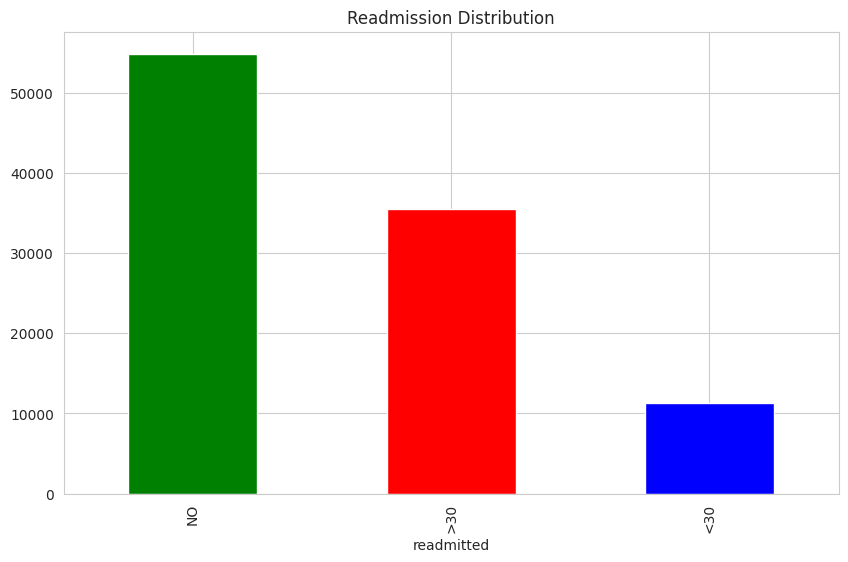

In [13]:
# Create a clean visualization
df['readmitted'].value_counts().plot(kind='bar', color=['green', 'red', 'blue'])
plt.title('Readmission Distribution')
plt.show()

### ⚠️ Critical Finding: Class Imbalance

Only **11.16%** of patients are readmitted within 30 days, while **88.84%** are not.

**Why this matters:**
- A model that predicts "NO readmission" for everyone would be 89% accurate but completely useless
- We need to identify the 11% high-risk patients to provide proper care
- This imbalance will require special handling techniques during model training

## 🔍 Missing Data Analysis

Real-world healthcare data is messy. Let's investigate missing values and decide how to handle them.

In [14]:
# First check - standard missing values
print("Standard NULL values found:", df.isnull().sum().sum())

Standard NULL values found: 181168


In [16]:
# Healthcare data often uses '?' for missing values - let's fix that
df.replace('?', np.nan, inplace=True)

print("Replaced '?' symbols with NaN (proper missing value marker)")
print(f"Total missing values now: {df.isnull().sum().sum():,}")

Replaced '?' symbols with NaN (proper missing value marker)
Total missing values now: 374,017


In [17]:
# Calculate missing percentage for each column
missing_pct = (df.isnull().sum() / len(df)) * 100
missing_pct = missing_pct[missing_pct > 0].sort_values(ascending=False)

print("Columns with Missing Data:")
print("=" * 60)
print(missing_pct.round(2))

Columns with Missing Data:
weight               96.86
max_glu_serum        94.75
A1Cresult            83.28
medical_specialty    49.08
payer_code           39.56
race                  2.23
diag_3                1.40
diag_2                0.35
diag_1                0.02
dtype: float64


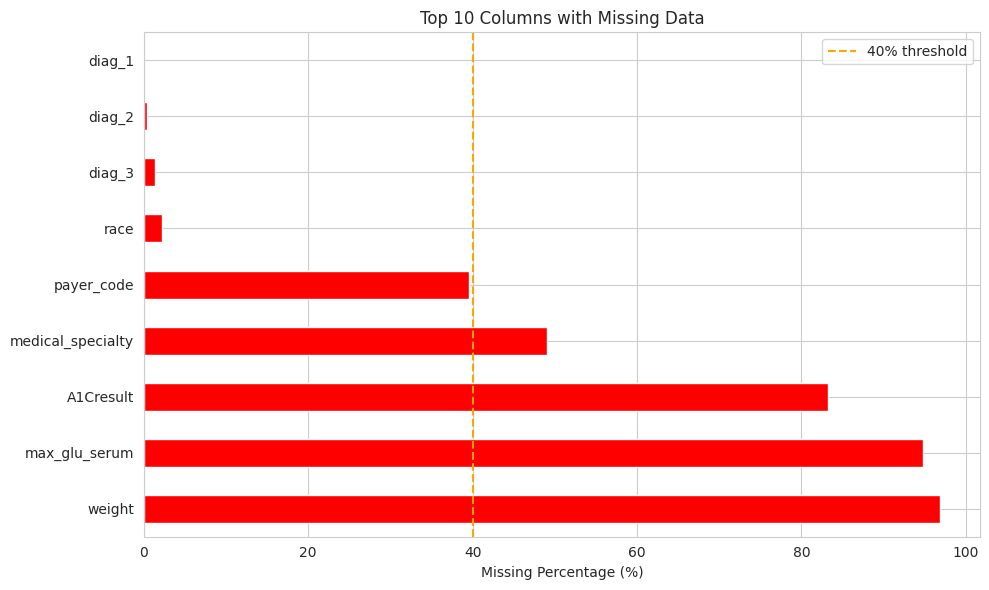

In [18]:
# Simple bar chart of missing data
missing_pct.head(10).plot(kind='barh', color='red')
plt.title('Top 10 Columns with Missing Data')
plt.xlabel('Missing Percentage (%)')
plt.axvline(x=40, color='orange', linestyle='--', label='40% threshold')
plt.legend()
plt.tight_layout()
plt.show()

### 📋 Missing Data Strategy

**Columns with >40% missing (will drop):**
- `weight` - 96.9% missing
- `max_glu_serum` - 94.7% missing  
- `A1Cresult` - 83.3% missing
- `medical_specialty` - 49.1% missing
- `payer_code` - 39.6% missing (also ethical concern - don't want insurance to affect predictions)

**Why drop these?** When 90%+ of data is missing, filling values creates more noise than signal.

In [19]:
# Drop columns with excessive missing data
cols_to_drop = ['weight', 'max_glu_serum', 'A1Cresult', 'medical_specialty', 'payer_code']
df = df.drop(columns=cols_to_drop)

print(f"Dropped {len(cols_to_drop)} columns")
print(f"New shape: {len(df):,} rows × {len(df.columns)} columns")

Dropped 5 columns
New shape: 101,766 rows × 45 columns


In [20]:
# Check what missing data remains
remaining_missing = (df.isnull().sum() / len(df)) * 100
remaining_missing = remaining_missing[remaining_missing > 0].sort_values(ascending=False)

print("Remaining Missing Data:")
print("=" * 60)
print(remaining_missing.round(2))

Remaining Missing Data:
race      2.23
diag_3    1.40
diag_2    0.35
diag_1    0.02
dtype: float64


### Handling Remaining Missing Values

**Small missing percentages (<3%):**
- `race` - 2.2% missing → Will drop these rows (losing 2% is acceptable with 100k+ records)
- `diag_1, diag_2, diag_3` - <2% missing → Will fill with 'Unknown' (these are diagnosis codes)

These diagnosis codes are important for prediction, so we'll keep them and treat missing as a separate category.

In [22]:
# Drop rows where race is missing
df = df.dropna(subset=['race'])

print(f"Dropped rows with missing race")
print(f"Current dataset: {len(df):,} rows")

Dropped rows with missing race
Current dataset: 99,493 rows


In [23]:
# Fill missing diagnosis codes with 'Unknown'
df['diag_1'] = df['diag_1'].fillna('Unknown')
df['diag_2'] = df['diag_2'].fillna('Unknown')
df['diag_3'] = df['diag_3'].fillna('Unknown')

print("Filled missing diagnosis codes with 'Unknown'")

Filled missing diagnosis codes with 'Unknown'


In [26]:
# Verify no missing values remain
total_missing = df.isnull().sum().sum()

print("=" * 60)
print("FINAL DATA QUALITY CHECK")
print("=" * 60)
print(f"Total missing values: {total_missing}")

if total_missing == 0:
    print("\n SUCCESS! Dataset is completely clean!")
else:
    print("\n Still have missing values:")
    print(df.isnull().sum()[df.isnull().sum() > 0])

FINAL DATA QUALITY CHECK
Total missing values: 0

 SUCCESS! Dataset is completely clean!


## 📊 Data Cleaning Summary

### What We Started With:
- 101,766 rows × 50 columns
- Massive missing data (96% in weight, 95% in glucose tests)
- '?' symbols instead of proper missing values
- Class imbalance (only 11% readmitted <30 days)

### What We Have Now:
- 99,493 rows × 45 columns
- **0 missing values** - completely clean!
- Removed 5 unreliable columns
- Lost only 2.2% of records (acceptable trade-off for data quality)

### Key Insights:
1. **Class imbalance is our biggest challenge** - need special techniques during modeling
2. **Healthcare data is messy** - requires careful cleaning decisions
3. **Domain knowledge matters** - dropped insurance data for ethical reasons

In [27]:
# Save the cleaned dataset
df.to_csv('diabetes_data_cleaned.csv', index=False)

print("Cleaned data saved successfully!")
print(f"File: diabetes_data_cleaned.csv")
print(f"Size: {len(df):,} rows × {len(df.columns)} columns")
print("\nNext step: Feature selection and engineering")

Cleaned data saved successfully!
File: diabetes_data_cleaned.csv
Size: 99,493 rows × 45 columns

Next step: Feature selection and engineering


## 🚀 Next Steps

**Part 2 will cover:**
1. Feature selection - choosing the most relevant columns
2. Exploratory analysis - understanding relationships between features and readmission
3. Feature engineering - creating new useful variables
4. Data preprocessing - preparing for machine learning

---